---
##  Quick Model Evaluation (Load Existing Model Only)

This section lets you load a trained model and evaluate it **without retraining**. 
Just run the cells below in order.

In [1]:
# ============================================================
# STEP 1: Configuration - Set your paths and model details
# ============================================================
from pathlib import Path
# CONFIGURATION - Modify these values as needed
DATA_PATH = Path('../data/test')           # Path to your test data (contains images/ & masks/)
MODEL_ARCHITECTURE = 'unet'             # Options: 'unet', 'deeplab', 'fcn', 'lraspp'
TRAINED_MODEL_NAME = 'unet_trained'             # Your saved model name (without extension)
NUM_CLASSES = 2                         # Number of classes (background + pin = 2)

print("Configuration set:")
print(f"   Data Path: {DATA_PATH}")
print(f"   Model: {MODEL_ARCHITECTURE}")
print(f"   Trained Model: {TRAINED_MODEL_NAME}")
print(f"   Classes: {NUM_CLASSES}")

Configuration set:
   Data Path: ../data/test
   Model: unet
   Trained Model: unet_trained
   Classes: 2


In [2]:
# ============================================================
# STEP 2: Load Data (DataLoader)
# ============================================================

from fastai.vision.all import *
from pathlib import Path
import numpy as np
import torch
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
random.seed(42)

# Define paths
path_images = DATA_PATH / 'images'
path_labels = DATA_PATH / 'masks'

# Define label codes
codes = np.array(['background', 'pin'])

# Custom mask remapping function
def remap_mask(path):
    mask = PILMask.create(path)
    mask_np = np.array(mask)
    mask_np = (mask_np > 0).astype(np.uint8)
    return PILMask.create(mask_np)

# Label function
def label_function(filename):
    return path_labels / Path(filename.stem + filename.suffix)

# Create DataBlock
batch_transforms = [*aug_transforms(size=512), Normalize.from_stats(*imagenet_stats)]

datablocks = DataBlock(
    blocks=(ImageBlock, MaskBlock(codes=codes)),
    get_items=get_image_files,
    get_y=lambda o: remap_mask(label_function(o)),
    splitter=RandomSplitter(seed=42),
    batch_tfms=batch_transforms
)

# Create DataLoader
data_loader = datablocks.dataloaders(path_images, bs=8, num_workers=8)

print(f"Data loaded: {len(data_loader.train_ds)} train, {len(data_loader.valid_ds)} valid samples")

Data loaded: 16 train, 3 valid samples


In [3]:
# ============================================================
# STEP 3: Create Model Architecture
# ============================================================

from fastai.vision.all import *
import torchvision.models as torchModels

# Define metrics
def original_accuracy(predictions, target):
    pred_hot1_decoded = predictions.argmax(dim=1)
    correct_predictions = (pred_hot1_decoded == target).float()
    return correct_predictions.mean()

def accuracy_pin(predictions, target):
    pred_hot1_decoded = predictions.argmax(dim=1)
    crack_in_target = target == 1
    correct_crack = torch.logical_and(crack_in_target, pred_hot1_decoded)
    correct_crack = correct_crack.float()
    return correct_crack.sum() / crack_in_target.float().sum()

metrics = [accuracy_pin, original_accuracy]

# Create model based on configuration
if MODEL_ARCHITECTURE == 'unet':
    learner = unet_learner(data_loader, resnet34, n_out=NUM_CLASSES, metrics=metrics, pretrained=True)
    
elif MODEL_ARCHITECTURE == 'deeplab':
    from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
    model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)
    model.classifier[4] = torch.nn.Conv2d(256, NUM_CLASSES, kernel_size=(1, 1), stride=(1, 1))
    
    class DeepLabV3Wrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            out = self.model(x)
            return out['out']
    
    wrapped_model = DeepLabV3Wrapper(model)
    learner = Learner(data_loader, wrapped_model, loss_func=DiceLoss(), metrics=metrics)
    
elif MODEL_ARCHITECTURE == 'fcn':
    from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
    model = fcn_resnet50(weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)
    model.classifier[4] = torch.nn.Conv2d(512, NUM_CLASSES, kernel_size=(1, 1), stride=(1, 1))
    
    # Wrap model to extract output from dict (FCN returns a dict, not a tensor)
    class FCNWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            out = self.model(x)
            return out['out']
    
    wrapped_model = FCNWrapper(model)
    learner = Learner(data_loader, wrapped_model, loss_func=DiceLoss(), metrics=metrics)
    
elif MODEL_ARCHITECTURE == 'lraspp':
    from torchvision.models.segmentation import lraspp_mobilenet_v3_large, LRASPP_MobileNet_V3_Large_Weights
    model = lraspp_mobilenet_v3_large(weights=LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1)
    model.classifier.low_classifier = torch.nn.Conv2d(40, NUM_CLASSES, kernel_size=(1, 1), stride=(1, 1))
    model.classifier.high_classifier = torch.nn.Conv2d(128, NUM_CLASSES, kernel_size=(1, 1), stride=(1, 1))
    
    # Wrap model to extract output from dict (LRASPP returns a dict, not a tensor)
    class LRASPPWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            out = self.model(x)
            return out['out']
    
    wrapped_model = LRASPPWrapper(model)
    learner = Learner(data_loader, wrapped_model, loss_func=DiceLoss(), metrics=metrics)

# Move to GPU
learner.to('cuda')

print(f"Model created: {MODEL_ARCHITECTURE}")

Model created: unet


In [4]:
# ============================================================
# STEP 4: Load Trained Weights 
# ============================================================

learner.load(TRAINED_MODEL_NAME)
print(f"Loaded trained model: {TRAINED_MODEL_NAME}")

Loaded trained model: unet_trained


In [5]:
# ============================================================
# STEP 5: Evaluate on Validation Set (Memory Efficient)
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import gc

def quick_evaluate(learner_to_eval, dl, model_name="Model", max_batches=50):
    """
    Quick evaluation on validation set - computes metrics incrementally
    to avoid memory issues with large images
    """
    learner_to_eval.model.eval()
    
    # Accumulate confusion matrix components incrementally
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_correct = 0
    total_pixels = 0
    
    batch_count = 0
    
    # Clear GPU memory before starting
    torch.cuda.empty_cache()
    gc.collect()
    
    with torch.no_grad():
        for xb, yb in dl:
            if batch_count >= max_batches:
                break
            
            try:
                # Get predictions
                logits = learner_to_eval.model(xb)
                if isinstance(logits, dict):
                    logits = logits['out']
                preds = logits.argmax(dim=1)
                
                # Move to CPU and convert to numpy
                preds_np = preds.cpu().numpy()
                targets_np = yb.cpu().numpy()
                
                # Free GPU tensors
                del logits, preds
                
                # Compute confusion matrix components for this batch
                # TP: predicted=1 AND target=1
                tp = ((preds_np == 1) & (targets_np == 1)).sum()
                # FP: predicted=1 AND target=0
                fp = ((preds_np == 1) & (targets_np == 0)).sum()
                # FN: predicted=0 AND target=1
                fn = ((preds_np == 0) & (targets_np == 1)).sum()
                # Correct: predicted == target
                correct = (preds_np == targets_np).sum()
                pixels = preds_np.size
                
                # Accumulate
                total_tp += int(tp)
                total_fp += int(fp)
                total_fn += int(fn)
                total_correct += int(correct)
                total_pixels += int(pixels)
                
                batch_count += 1
                
                # Free memory EVERY batch for UNet
                gc.collect()
                torch.cuda.empty_cache()
                    
            except Exception as e:
                print(f"Warning: Error processing batch {batch_count}: {e}")
                continue
    
    print(f"Processed {batch_count} batches, {total_pixels:,} total pixels")
    
    # Compute final metrics from accumulated values
    overall_acc = total_correct / total_pixels if total_pixels > 0 else 0
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    iou = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0
    
    # Display results
    print(f"\n{'='*60}")
    print(f"  Evaluation Results: {model_name}")
    print(f"{'='*60}")
    print(f"  Overall Accuracy:  {overall_acc:.4f} ({overall_acc*100:.2f}%)")
    print(f"  Precision (Pin):   {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall (Pin):      {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1-Score (Pin):    {f1:.4f} ({f1*100:.2f}%)")
    print(f"  IoU (Pin):         {iou:.4f} ({iou*100:.2f}%)")
    print(f"{'='*60}")
    print(f"  True Positives:    {total_tp}")
    print(f"  False Positives:   {total_fp}")
    print(f"  False Negatives:   {total_fn}")
    print(f"{'='*60}\n")
    
    return {
        'model_name': model_name,
        'overall_accuracy': overall_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'iou': iou 
    }

# Run evaluation with limited batches to prevent OOM
# For UNet, reduce max_batches if still crashing
eval_result = quick_evaluate(learner, learner.dls.valid, model_name=TRAINED_MODEL_NAME, max_batches=20) 
#max_batches=20 for UNet, can increase for smaller models (e.g. 30-50 for DeepLab/LRAspp)

Processed 1 batches, 786,432 total pixels

  Evaluation Results: unet_trained
  Overall Accuracy:  0.9808 (98.08%)
  Precision (Pin):   0.9369 (93.69%)
  Recall (Pin):      0.7679 (76.79%)
  F1-Score (Pin):    0.8440 (84.40%)
  IoU (Pin):         0.7302 (73.02%)
  True Positives:    40947
  False Positives:   2756
  False Negatives:   12377



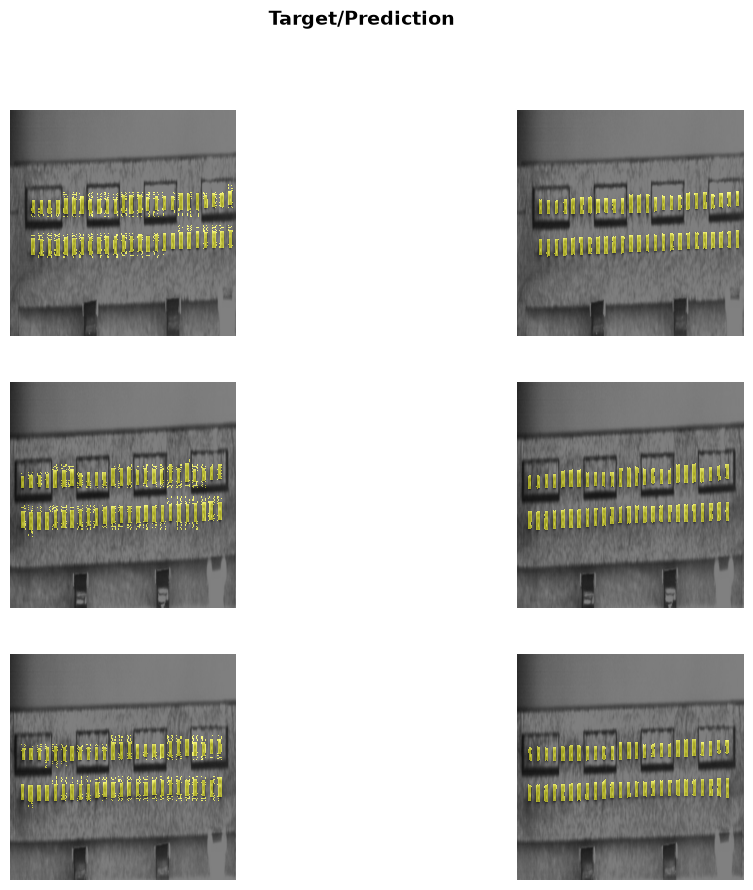

In [6]:
# ============================================================
# STEP 6: Visualize Some Predictions
# ============================================================
# custom ColorMap
import matplotlib as mp
cpts = [0.0, 0.5, 1.0]
colors = [(cpts[0], (0, 0, 0)), (cpts[1], (1.0, 0.0, 0.0)), (cpts[2], (1, 1, 0))]
cmap_name = 'my_list'
colormap = mp.colors.LinearSegmentedColormap.from_list(cmap_name, colors)


learner.show_results(max_n=4, figsize=(12,10), vmin=0, vmax=1, cmap=colormap)